### Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/Users/kondareddyd/Jupyter
['s4182304.ipynb', 'diabetic_data.csv', '.ipynb_checkpoints', 'BEED_Data.csv']


In [3]:
diabetes = pd.read_csv("diabetic_data.csv")
beed = pd.read_csv("BEED_Data.csv")

print("Diabetes shape:", diabetes.shape)
print("BEED shape:", beed.shape)

Diabetes shape: (101766, 50)
BEED shape: (8000, 17)


In [4]:
print(diabetes.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [5]:
print(beed.head())

    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  


### Target variable distribution

In [6]:
print("Diabetes target:")
print(diabetes["readmitted"].value_counts())

print("\nBEED target:")
print(beed["y"].value_counts())

Diabetes target:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

BEED target:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


### Diabetes Data Preprocessing

In [7]:
diabetes_clean = diabetes.copy()

diabetes_clean = diabetes_clean.drop(
    ["encounter_id", "patient_nbr", "weight",
     "medical_specialty", "payer_code"],
    axis=1
)

diabetes_clean = diabetes_clean.replace("?", "Unknown")

print(diabetes_clean.shape)

(101766, 45)


In [8]:
X_diabetes = diabetes_clean.drop("readmitted", axis=1)
y_diabetes = diabetes_clean["readmitted"]

print("X shape:", X_diabetes.shape)
print("y shape:", y_diabetes.shape)

X shape: (101766, 44)
y shape: (101766,)


### Train-Test Split

In [9]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.2,
    stratify=y_diabetes,
    random_state=2023
)

print("Training data:", X_train_d.shape)
print("Testing data:", X_test_d.shape)

Training data: (81412, 44)
Testing data: (20354, 44)


In [10]:
for column in X_train_d.columns:
    if pd.api.types.is_numeric_dtype(X_train_d[column]):
        median_value = X_train_d[column].median()
        X_train_d[column] = X_train_d[column].fillna(median_value)
        X_test_d[column] = X_test_d[column].fillna(median_value)
    else:
        X_train_d[column] = X_train_d[column].fillna("Unknown")
        X_test_d[column] = X_test_d[column].fillna("Unknown")

### Categorical Encoding

In [11]:
X_train_d = pd.get_dummies(X_train_d, drop_first=True)
X_test_d = pd.get_dummies(X_test_d, drop_first=True)

X_test_d = X_test_d.reindex(
    columns=X_train_d.columns,
    fill_value=0
)

print("Training data after encoding:", X_train_d.shape)
print("Testing data after encoding:", X_test_d.shape)

Training data after encoding: (81412, 2274)
Testing data after encoding: (20354, 2274)


In [12]:
print("Training missing values:", X_train_d.isnull().sum().sum())
print("Testing missing values:", X_test_d.isnull().sum().sum())

Training missing values: 0
Testing missing values: 0


### Feature Scaling for KNN

In [13]:
scaler_d = StandardScaler()

X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

print("Training scaled shape:", X_train_d_scaled.shape)
print("Testing scaled shape:", X_test_d_scaled.shape)

Training scaled shape: (81412, 2274)
Testing scaled shape: (20354, 2274)


### Random Forest Analysis
### Diabetes Random Forest

In [14]:
rf_d = RandomForestClassifier(
    n_estimators=100,
    random_state=2023,
    n_jobs=-1
)

rf_d.fit(X_train_d, y_train_d)

rf_pred_d = rf_d.predict(X_test_d)

In [15]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test_d, rf_pred_d))
print("Precision:", precision_score(y_test_d, rf_pred_d, average="macro"))
print("Recall:", recall_score(y_test_d, rf_pred_d, average="macro"))
print("F1:", f1_score(y_test_d, rf_pred_d, average="macro"))

Random Forest
Accuracy: 0.581409059644296
Precision: 0.569406555593684
Recall: 0.40997718815709144
F1: 0.38839092875862075


### Diabetes Random Forest Classification Report

In [16]:
print(classification_report(y_test_d, rf_pred_d))

              precision    recall  f1-score   support

         <30       0.60      0.01      0.02      2272
         >30       0.49      0.41      0.45      7109
          NO       0.62      0.81      0.70     10973

    accuracy                           0.58     20354
   macro avg       0.57      0.41      0.39     20354
weighted avg       0.57      0.58      0.54     20354



In [17]:
cm_rf_d = confusion_matrix(y_test_d, rf_pred_d)

print(cm_rf_d)

[[  18  999 1255]
 [   9 2931 4169]
 [   3 2085 8885]]


### Diabetes Random Forest Feature Importance

In [18]:
importance = pd.Series(
    rf_d.feature_importances_,
    index=X_train_d.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(10))

num_lab_procedures          0.052393
num_medications             0.049531
time_in_hospital            0.038286
number_inpatient            0.034306
number_diagnoses            0.029031
discharge_disposition_id    0.028793
num_procedures              0.025806
admission_type_id           0.020011
admission_source_id         0.016916
number_outpatient           0.015553
dtype: float64


In [19]:
X_beed = beed.drop("y", axis=1)
y_beed = beed["y"]

In [20]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_beed,
    y_beed,
    test_size=0.2,
    stratify=y_beed,
    random_state=2023
)

In [21]:
scaler_b = StandardScaler()

X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

### K-Nearest Neighbours (KNN) Analysis

In [22]:
X_train_knn_b, X_valid_knn_b, y_train_knn_b, y_valid_knn_b = train_test_split(
    X_train_b,
    y_train_b,
    test_size=0.2,
    stratify=y_train_b,
    random_state=2023
)

scaler_knn_b = StandardScaler()

X_train_knn_b_scaled = scaler_knn_b.fit_transform(X_train_knn_b)
X_valid_knn_b_scaled = scaler_knn_b.transform(X_valid_knn_b)

print("BEED KNN training data:", X_train_knn_b_scaled.shape)
print("BEED KNN validation data:", X_valid_knn_b_scaled.shape)

BEED KNN training data: (5120, 16)
BEED KNN validation data: (1280, 16)


In [23]:
k_values = [3, 5, 7, 9, 11]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_knn_b_scaled, y_train_knn_b)

    pred = knn.predict(X_valid_knn_b_scaled)

    accuracy = accuracy_score(y_valid_knn_b, pred)
    f1 = f1_score(y_valid_knn_b, pred, average="macro")

    print("k =", k)
    print("Accuracy:", accuracy)
    print("Macro F1:", f1)
    print()

k = 3
Accuracy: 0.9546875
Macro F1: 0.9549368591516114

k = 5
Accuracy: 0.93671875
Macro F1: 0.9370138465510032

k = 7
Accuracy: 0.91484375
Macro F1: 0.9152066119452857

k = 9
Accuracy: 0.9078125
Macro F1: 0.9082705244318415

k = 11
Accuracy: 0.89140625
Macro F1: 0.8919606426008343



In [24]:
best_k_b = 3

knn_b = KNeighborsClassifier(n_neighbors=best_k_b)

knn_b.fit(X_train_b_scaled, y_train_b)

knn_pred_b = knn_b.predict(X_test_b_scaled)

print("BEED KNN")
print("Accuracy:", accuracy_score(y_test_b, knn_pred_b))
print("Precision:", precision_score(y_test_b, knn_pred_b, average="macro"))
print("Recall:", recall_score(y_test_b, knn_pred_b, average="macro"))
print("F1:", f1_score(y_test_b, knn_pred_b, average="macro"))

BEED KNN
Accuracy: 0.97625
Precision: 0.9768174345413403
Recall: 0.9762500000000001
F1: 0.9762799990230034


In [25]:
X_train_knn, X_valid_knn, y_train_knn, y_valid_knn = train_test_split(
    X_train_d,
    y_train_d,
    test_size=0.2,
    stratify=y_train_d,
    random_state=2023
)

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_valid_knn_scaled = scaler_knn.transform(X_valid_knn)

print("KNN training data:", X_train_knn_scaled.shape)
print("KNN validation data:", X_valid_knn_scaled.shape)

KNN training data: (65129, 2274)
KNN validation data: (16283, 2274)


In [26]:
k_values = [3, 5, 7, 9, 11]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_knn_scaled, y_train_knn)

    pred = knn.predict(X_valid_knn_scaled)

    accuracy = accuracy_score(y_valid_knn, pred)
    f1 = f1_score(y_valid_knn, pred, average="macro")

    print("k =", k)
    print("Accuracy:", accuracy)
    print("Macro F1:", f1)
    print()

k = 3
Accuracy: 0.4513296075661733
Macro F1: 0.36126340307179383

k = 5
Accuracy: 0.48129951483141925
Macro F1: 0.3700110856482488

k = 7
Accuracy: 0.4984339495179021
Macro F1: 0.35865224441696136

k = 9
Accuracy: 0.5035312903027698
Macro F1: 0.3559157554592925

k = 11
Accuracy: 0.5098569059755573
Macro F1: 0.3501362099580203



In [27]:
best_k = 5

knn_d = KNeighborsClassifier(n_neighbors=best_k)

knn_d.fit(X_train_d_scaled, y_train_d)

knn_pred_d = knn_d.predict(X_test_d_scaled)

print("Diabetes KNN")
print("Accuracy:", accuracy_score(y_test_d, knn_pred_d))
print("Precision:", precision_score(y_test_d, knn_pred_d, average="macro"))
print("Recall:", recall_score(y_test_d, knn_pred_d, average="macro"))
print("F1:", f1_score(y_test_d, knn_pred_d, average="macro"))

Diabetes KNN
Accuracy: 0.5046182568536897
Precision: 0.37916949897532154
Recall: 0.3674784710398497
F1: 0.3618470740880746


In [28]:
cm_knn_d = confusion_matrix(y_test_d, knn_pred_d)

print("Diabetes KNN confusion matrix:")
print(cm_knn_d)

Diabetes KNN confusion matrix:
[[ 186  633 1453]
 [ 414 2049 4646]
 [ 505 2432 8036]]


### BEED Random Forest model

In [29]:
rf_b = RandomForestClassifier(
    n_estimators=100,
    random_state=2023,
    n_jobs=-1
)

rf_b.fit(X_train_b, y_train_b)

rf_pred_b = rf_b.predict(X_test_b)

In [30]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test_b, rf_pred_b))
print("Precision:", precision_score(y_test_b, rf_pred_b, average="macro"))
print("Recall:", recall_score(y_test_b, rf_pred_b, average="macro"))
print("F1:", f1_score(y_test_b, rf_pred_b, average="macro"))

Random Forest
Accuracy: 0.965
Precision: 0.9653765738308567
Recall: 0.965
F1: 0.9650577677967315


### BEED KNN Model

In [31]:
knn_b = KNeighborsClassifier(n_neighbors=3)

knn_b.fit(X_train_b_scaled, y_train_b)

knn_pred_b = knn_b.predict(X_test_b_scaled)

In [32]:
print("KNN")
print("Accuracy:", accuracy_score(y_test_b, knn_pred_b))
print("Precision:", precision_score(y_test_b, knn_pred_b, average="macro"))
print("Recall:", recall_score(y_test_b, knn_pred_b, average="macro"))
print("F1:", f1_score(y_test_b, knn_pred_b, average="macro"))

KNN
Accuracy: 0.97625
Precision: 0.9768174345413403
Recall: 0.9762500000000001
F1: 0.9762799990230034


In [33]:
cm_rf_b = confusion_matrix(y_test_b, rf_pred_b)

print("BEED Random Forest confusion matrix:")
print(cm_rf_b)

cm_knn_b = confusion_matrix(y_test_b, knn_pred_b)

print("\nBEED KNN confusion matrix:")
print(cm_knn_b)

BEED Random Forest confusion matrix:
[[398   2   0   0]
 [  0 378  11  11]
 [  0   2 384  14]
 [  2   3  11 384]]

BEED KNN confusion matrix:
[[398   1   0   1]
 [  0 385   9   6]
 [  0   2 381  17]
 [  0   1   1 398]]


In [34]:
importance_b = pd.Series(
    rf_b.feature_importances_,
    index=X_train_b.columns
)

importance_b = importance_b.sort_values(ascending=False)

print("Top 10 BEED features:")
print(importance_b.head(10))

Top 10 BEED features:
X8     0.116467
X16    0.110158
X11    0.079684
X15    0.078802
X12    0.068865
X7     0.065926
X6     0.064071
X1     0.056539
X9     0.056140
X10    0.048905
dtype: float64


### Diabetes KNN Performance Graph

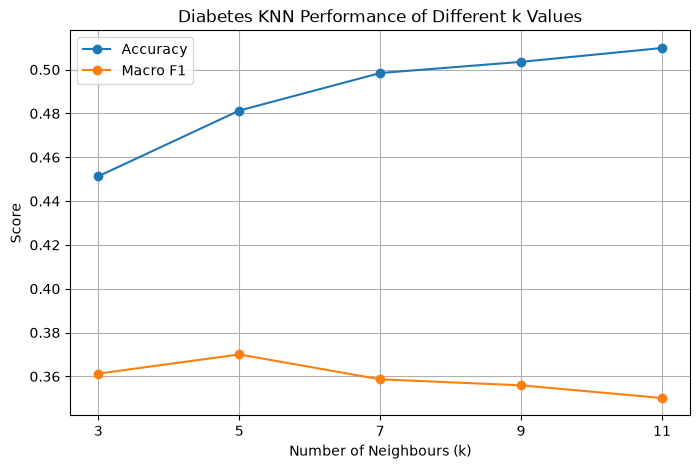

In [35]:
k_values = [3, 5, 7, 9, 11]

accuracy_values = [
    0.4513296076,
    0.4812995148,
    0.4984339495,
    0.5035312903,
    0.5098569060
]

f1_values = [
    0.3612634031,
    0.3700110856,
    0.3586522444,
    0.3559157555,
    0.3501362100
]

plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracy_values, marker="o", label="Accuracy")
plt.plot(k_values, f1_values, marker="o", label="Macro F1")

plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Score")
plt.title("Diabetes KNN Performance of Different k Values")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

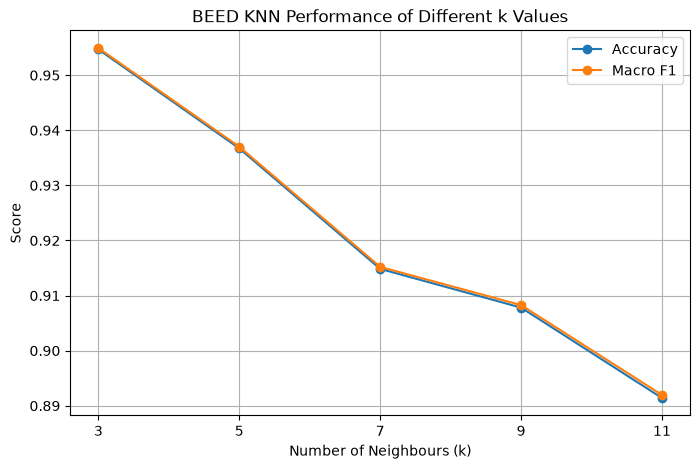

In [36]:
k_values_b = [3, 5, 7, 9, 11]

accuracy_values_b = [
    0.9546875,
    0.93671875,
    0.91484375,
    0.9078125,
    0.89140625
]

f1_values_b = [
    0.9549368592,
    0.9370138466,
    0.9152066119,
    0.9082705244,
    0.8919606426
]

plt.figure(figsize=(8, 5))

plt.plot(k_values_b, accuracy_values_b, marker="o", label="Accuracy")
plt.plot(k_values_b, f1_values_b, marker="o", label="Macro F1")

plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Score")
plt.title("BEED KNN Performance of Different k Values")
plt.xticks(k_values_b)
plt.legend()
plt.grid(True)

plt.show()

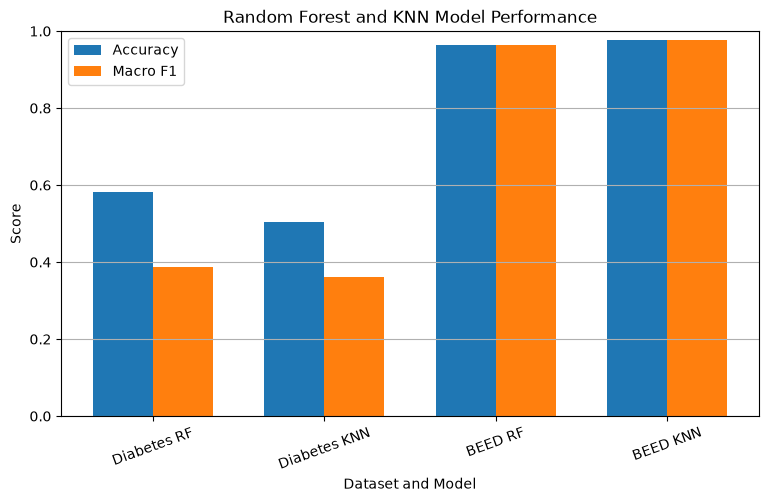

In [37]:
models = ["Diabetes RF", "Diabetes KNN", "BEED RF", "BEED KNN"]

accuracy_scores = [
    0.5814090596,
    0.5046182569,
    0.965,
    0.97625
]

f1_scores = [
    0.3883909288,
    0.3618470741,
    0.9650577678,
    0.97628
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, accuracy_scores, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="Macro F1")

plt.xlabel("Dataset and Model")
plt.ylabel("Score")
plt.title("Random Forest and KNN Model Performance")
plt.xticks(x, models, rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

plt.show()

In [38]:
results = pd.DataFrame({
    "Dataset": ["Diabetes", "Diabetes", "BEED", "BEED"],
    "Model": ["Random Forest", "KNN", "Random Forest", "KNN"],
    "Accuracy": [0.581409, 0.504618, 0.965000, 0.976250],
    "Precision": [0.569407, 0.379169, 0.965377, 0.976817],
    "Recall": [0.409977, 0.367478, 0.965000, 0.976250],
    "Macro F1": [0.388391, 0.361847, 0.965058, 0.976280]
})

print(results)

    Dataset          Model  Accuracy  Precision    Recall  Macro F1
0  Diabetes  Random Forest  0.581409   0.569407  0.409977  0.388391
1  Diabetes            KNN  0.504618   0.379169  0.367478  0.361847
2      BEED  Random Forest  0.965000   0.965377  0.965000  0.965058
3      BEED            KNN  0.976250   0.976817  0.976250  0.976280


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

sizes = [500, 1000, 2000, 4000]

train_accuracy = []
valid_accuracy = []

train_f1 = []
valid_f1 = []

indices = np.arange(len(y_train_knn_b))

for n in sizes:
    
    idx, _ = train_test_split(
        indices,
        train_size=n,
        stratify=y_train_knn_b,
        random_state=2023 + n
    )
    
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(
        X_train_knn_b_scaled[idx],
        y_train_knn_b.iloc[idx]
    )
    
    train_pred = model.predict(X_train_knn_b_scaled[idx])
    valid_pred = model.predict(X_valid_knn_b_scaled)
    
    train_accuracy.append(
        accuracy_score(y_train_knn_b.iloc[idx], train_pred)
    )
    
    valid_accuracy.append(
        accuracy_score(y_valid_knn_b, valid_pred)
    )
    
    train_f1.append(
        f1_score(
            y_train_knn_b.iloc[idx],
            train_pred,
            average="macro"
        )
    )
    
    valid_f1.append(
        f1_score(
            y_valid_knn_b,
            valid_pred,
            average="macro"
        )
    )

print("Training sizes:", sizes)
print("Training accuracy:", train_accuracy)
print("Validation accuracy:", valid_accuracy)
print("Training Macro F1:", train_f1)
print("Validation Macro F1:", valid_f1)

Training sizes: [500, 1000, 2000, 4000]
Training accuracy: [0.902, 0.935, 0.9605, 0.983]
Validation accuracy: [0.7671875, 0.821875, 0.87734375, 0.94140625]
Training Macro F1: [0.9029981766746796, 0.9352150432008788, 0.9606438287905719, 0.9830293944691502]
Validation Macro F1: [0.7665719334608654, 0.8222601170083268, 0.8784433720968993, 0.9418105222670992]


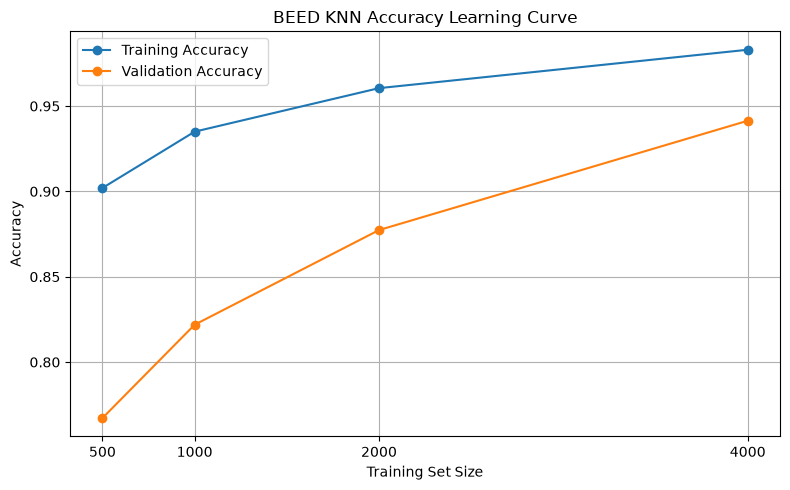

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    sizes,
    valid_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("BEED KNN Accuracy Learning Curve")
plt.xticks(sizes)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "BEED_KNN_accuracy_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

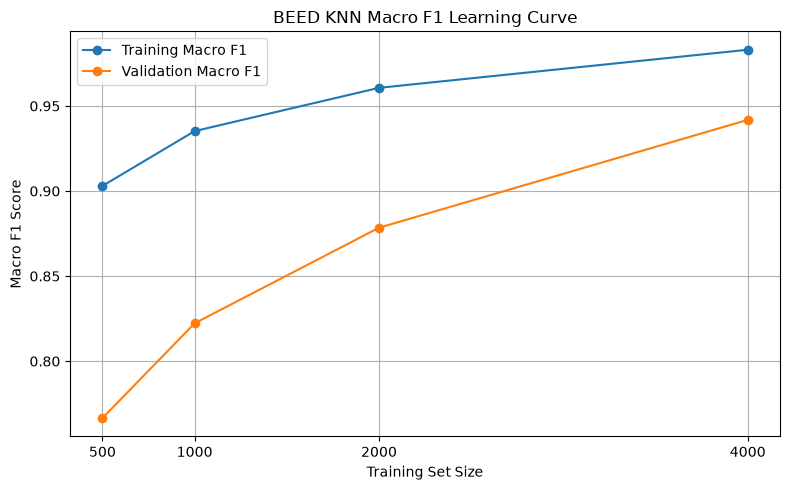

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    train_f1,
    marker="o",
    label="Training Macro F1"
)

plt.plot(
    sizes,
    valid_f1,
    marker="o",
    label="Validation Macro F1"
)

plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.title("BEED KNN Macro F1 Learning Curve")
plt.xticks(sizes)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "BEED_KNN_macro_F1_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
learning_curve_results = pd.DataFrame({
    "Training Size": sizes,
    "Training Accuracy": train_accuracy,
    "Validation Accuracy": valid_accuracy,
    "Training Macro F1": train_f1,
    "Validation Macro F1": valid_f1
})

learning_curve_results

,Training Size,Training Accuracy,Validation Accuracy,Training Macro F1,Validation Macro F1
0,500,0.9020,0.767188,0.902998,0.766572
1,1000,0.9350,0.821875,0.935215,0.822260
2,2000,0.9605,0.877344,0.960644,0.878443
3,4000,0.9830,0.941406,0.983029,0.941811


In [45]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score, f1_score

# Sensitive attributes from the original test data
race = diabetes.loc[X_test_d.index, "race"]
gender = diabetes.loc[X_test_d.index, "gender"]
age = diabetes.loc[X_test_d.index, "age"]

# Metrics
metrics = {
    "Accuracy": accuracy_score,
    "Macro F1": lambda y_true, y_pred: f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
}

# Race
race_fairness = MetricFrame(
    metrics=metrics,
    y_true=y_test_d,
    y_pred=rf_pred_d,
    sensitive_features=race
)

print("Fairness by Race:")
print(race_fairness.by_group)

print("\nRace difference:")
print(race_fairness.difference())

# Gender
gender_fairness = MetricFrame(
    metrics=metrics,
    y_true=y_test_d,
    y_pred=rf_pred_d,
    sensitive_features=gender
)

print("\nFairness by Gender:")
print(gender_fairness.by_group)

print("\nGender difference:")
print(gender_fairness.difference())

# Age
age_fairness = MetricFrame(
    metrics=metrics,
    y_true=y_test_d,
    y_pred=rf_pred_d,
    sensitive_features=age
)

print("\nFairness by Age:")
print(age_fairness.by_group)

print("\nAge difference:")
print(age_fairness.difference())

Fairness by Race:
                 Accuracy  Macro F1
race                               
?                0.717021  0.362377
AfricanAmerican  0.584837  0.386739
Asian            0.614035  0.300693
Caucasian        0.572940  0.387164
Hispanic         0.652174  0.412293
Other            0.642173  0.397329

Race difference:
Accuracy    0.144081
Macro F1    0.111601
dtype: float64

Fairness by Gender:
                 Accuracy  Macro F1
gender                             
Female           0.579860  0.392511
Male             0.583191  0.383078
Unknown/Invalid  1.000000  1.000000

Gender difference:
Accuracy    0.420140
Macro F1    0.616922
dtype: float64

Fairness by Age:
          Accuracy  Macro F1
age                         
[0-10)    0.727273  0.345455
[10-20)   0.693750  0.427897
[20-30)   0.626984  0.476910
[30-40)   0.640152  0.428069
[40-50)   0.615185  0.406427
[50-60)   0.619808  0.411987
[60-70)   0.591206  0.395326
[70-80)   0.541635  0.360778
[80-90)   0.548282  0.370085
[90-

In [46]:
print("Race group counts:")
print(race.value_counts())

print("\nGender group counts:")
print(gender.value_counts())

print("\nAge group counts:")
print(age.value_counts())

Race group counts:
race
Caucasian          15218
AfricanAmerican     3825
?                    470
Hispanic             414
Other                313
Asian                114
Name: count, dtype: int64

Gender group counts:
gender
Female             11013
Male                9340
Unknown/Invalid        1
Name: count, dtype: int64

Age group counts:
age
[70-80)     5236
[60-70)     4435
[50-60)     3443
[80-90)     3376
[40-50)     1923
[30-40)      792
[90-100)     578
[20-30)      378
[10-20)      160
[0-10)        33
Name: count, dtype: int64
